In [1]:
import os
import sys
import json
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../BACKEND"))

# Import functions directly from pipeline.py
try:
    from pipeline import load_api_key, pipeline
except Exception:
    import importlib.util
    backend_dir = os.path.abspath(os.path.join(os.path.dirname(__file__) if '__file__' in globals() else os.getcwd(), "../BACKEND"))
    pipeline_path = os.path.join(backend_dir, "pipeline.py")
    spec = importlib.util.spec_from_file_location("pipeline", pipeline_path)
    pipeline_module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(pipeline_module)
    load_api_key = pipeline_module.load_api_key
    pipeline = pipeline_module.pipeline

In [3]:
api_key = load_api_key()
# el = pipeline(api_key=api_key, platform='EUW1', player_name='401dmg', player_tag='6969', count=1, save=1) #H2P_Gucio

from pathlib import Path

base_dir = Path.cwd()
data = {}

for file_path in sorted(base_dir.glob('data/*.json')):
    with open(file_path, encoding='utf-8') as f:
        data.update(json.load(f))

print(f'Loaded {len(data)} matches from {len(list(base_dir.glob("*.json")))} files.')

Loaded 1792 matches from 0 files.


Dropping unnecesarry columns with irrelevant data

In [4]:
players = []
for match in data.values():
    for player in match['players']:
        players.append(player)
        
    df = pd.DataFrame(players)    
    df = df.drop(columns=['username', 'championImageLink', 'summonerLevel', 'teamId', 'goldEarned', 'needVisionPings', 'enemyVisionPings', 'allInPings', 'pushPings',
        'assistMePings', 'commandPings', 'dangerPings', 'enemyMissingPings', 'gameEndedInSurrender',
        'onMyWayPings', 'retreatPings', 'icon', 'caller', 'masteries'])
        
    df = df.set_index('puuid')

Handling nested json object

In [5]:
df["summoner_1"] = df["summoners"].str[0].str["name"]
df["summoner_2"] = df["summoners"].str[1].str["name"]
df = df.drop(columns=['summoners', 'runes', 'items', 'metadata'])

Splitting summoner spells 

In [6]:
summs_ohe = pd.get_dummies(df[["summoner_1", "summoner_2"]], dtype=int)

spell_to_columns = {}
for col in summs_ohe.columns:
    spell_name = col.replace("summoner_1_", "").replace("summoner_2_", "")
    spell_to_columns.setdefault(spell_name, []).append(col)

summoners_encoded = pd.DataFrame(
    {f"summoner_{spell}": summs_ohe[cols].max(axis=1) for spell, cols in spell_to_columns.items()},
    index=df.index,
    )

final_df = pd.concat([df, summoners_encoded], axis=1)

In [7]:
final_df = final_df.drop(columns=['summoner_1', 'summoner_2'])

In [8]:
final_df.head()

,teamPosition,championName,kills,deaths,assists,champLevel,KDA,killParticipation,skillshotsDodged,skillshotsHit,...,totalTimeSpentDead,summoner_Barrier,summoner_Cleanse,summoner_Exhaust,summoner_Flash,summoner_Ghost,summoner_Heal,summoner_Ignite,summoner_Smite,summoner_Teleport
puuid,,,,,,,,,,,,,,,,,,,,,
pGhVZBhQmSIjCvvbcqwBBfya1PYsSFCzEpub8bq-ZCVHrX6bpnqfThGwgrhyQ9jOCeaKA-_tih_PPQ,TOP,Vayne,4,7,1,16,0.71,26.32,53,43,...,222,0,0,0,1,0,0,1,0,0
Cirl76CDa7i-vvSvpXYS1fye9-af95QCghZasE8PqDMClfzY8dOzTron2yFBpFciGLyLe6lDl4zlIg,JUNGLE,Briar,12,9,0,14,1.33,63.16,135,10,...,268,0,0,0,1,0,0,0,1,0
a8MigVf7em2qPPRbMWte5GMdWtFKskFYuB6jeecI_APDWojiNr_UjwZyAbg1RNC-UKmdXR9eIl35Rg,MIDDLE,Malzahar,1,12,4,14,0.42,26.32,106,0,...,310,0,0,0,1,0,0,0,0,1
X43TXf-RmfFH5qdoqotv7Y1PM0oA8uXceenJyV_FjfG2QmGI-E0UWL0O69QQVgSiK_PCt0Gl_3i3sw,BOTTOM,Jinx,2,7,1,13,0.43,15.79,115,25,...,171,1,0,0,1,0,0,0,0,0
sNslXgYTos3LFH2vfrXm8GyIITTVG-QkjWk4IZcJamWpoybozaqKOHweWdCSYjdA6ajuqYJuF8dEnQ,UTILITY,Morgana,0,10,5,13,0.50,26.32,130,13,...,209,0,0,0,1,0,0,1,0,0


Spliting data into index table and statistics values table

In [10]:
index_table_df = final_df[["teamPosition", "championName"]].copy()
index_table_df.insert(0, "puuid", final_df.index)

numerical_stats_df = final_df.drop(columns=["teamPosition", "championName"])
numerical_stats_df['win'] = numerical_stats_df['win'].astype(int)
numerical_stats_df = numerical_stats_df.select_dtypes(include=["number"]).copy()

Normalization of values inside stats table. Min-max normalization to values $x \in [0, 1]$

In [11]:
# Min-max normalization to [0, 1]
normalized_stats_df = numerical_stats_df.copy()

for col in normalized_stats_df.columns:
    min_col_value = normalized_stats_df[col].min()
    max_col_value = normalized_stats_df[col].max()

    if max_col_value == min_col_value:
        normalized_stats_df[col] = 0.0
    else:
        normalized_stats_df[col] = (
            (normalized_stats_df[col] - min_col_value)
            / (max_col_value - min_col_value)
        )

Coefficent matrix is plotted to verify data connections.

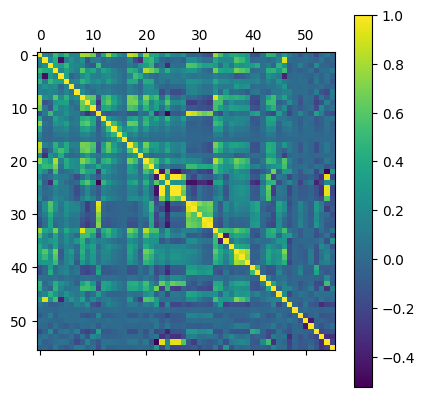

In [12]:
plt.matshow(normalized_stats_df.corr())
plt.colorbar()

In [13]:
normalized_stats_df.head()

,kills,deaths,assists,champLevel,KDA,killParticipation,skillshotsDodged,skillshotsHit,damagePerMinute,goldPerMinute,...,totalTimeSpentDead,summoner_Barrier,summoner_Cleanse,summoner_Exhaust,summoner_Flash,summoner_Ghost,summoner_Heal,summoner_Ignite,summoner_Smite,summoner_Teleport
puuid,,,,,,,,,,,,,,,,,,,,,
pGhVZBhQmSIjCvvbcqwBBfya1PYsSFCzEpub8bq-ZCVHrX6bpnqfThGwgrhyQ9jOCeaKA-_tih_PPQ,0.102564,0.269231,0.019608,0.789474,0.01775,0.2632,0.112051,0.026708,0.189315,0.309316,...,0.219151,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
Cirl76CDa7i-vvSvpXYS1fye9-af95QCghZasE8PqDMClfzY8dOzTron2yFBpFciGLyLe6lDl4zlIg,0.307692,0.346154,0.000000,0.684211,0.03325,0.6316,0.285412,0.006211,0.180018,0.527712,...,0.264561,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
a8MigVf7em2qPPRbMWte5GMdWtFKskFYuB6jeecI_APDWojiNr_UjwZyAbg1RNC-UKmdXR9eIl35Rg,0.025641,0.461538,0.078431,0.684211,0.01050,0.2632,0.224101,0.000000,0.161001,0.323403,...,0.306022,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
X43TXf-RmfFH5qdoqotv7Y1PM0oA8uXceenJyV_FjfG2QmGI-E0UWL0O69QQVgSiK_PCt0Gl_3i3sw,0.051282,0.269231,0.019608,0.631579,0.01075,0.1579,0.243129,0.015528,0.089531,0.352697,...,0.168806,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
sNslXgYTos3LFH2vfrXm8GyIITTVG-QkjWk4IZcJamWpoybozaqKOHweWdCSYjdA6ajuqYJuF8dEnQ,0.000000,0.384615,0.098039,0.631579,0.01250,0.2632,0.274841,0.008075,0.155572,0.193274,...,0.206318,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


Association rules for the win attribute use a binary view of the normalized stats. In this notebook, trust is treated as confidence.

In [14]:
from mlxtend.frequent_patterns import apriori, association_rules

# Convert normalized values into presence/absence items for rule mining
# 'high_' means the normalized value is at least 0.5.
binary_stats_df = normalized_stats_df.drop(columns=['win']).ge(0.5)
binary_stats_df = binary_stats_df.rename(columns=lambda col: f'high_{col}')
binary_stats_df['win'] = normalized_stats_df['win'].ge(0.5)

frequent_itemsets = apriori(binary_stats_df, min_support=0.1, use_colnames=True)

if frequent_itemsets.shape[0] < 1:
    win_rules = pd.DataFrame(columns=['antecedents', 'consequents', 'support', 'trust', 'lift'])
else:
    rules = association_rules(frequent_itemsets, metric='confidence', min_threshold=0.6)
    win_rules = rules[rules['consequents'] == frozenset({'win'})].copy()
    win_rules['trust'] = win_rules['confidence']
    win_rules = win_rules.sort_values(['trust', 'support', 'lift'], ascending=False)

def itemset_to_text(itemset):
    readable_items = []
    for item in sorted(itemset):
        if item == 'win':
            readable_items.append('win')
        elif item.startswith('high_'):
            readable_items.append(f'high {item[5:]}')
        else:
            readable_items.append(item)
    return ' and '.join(readable_items)

win_rules_display = win_rules.assign(
    antecedents=win_rules['antecedents'].map(itemset_to_text),
    consequents=win_rules['consequents'].map(itemset_to_text),
    support=win_rules['support'].round(3),
    trust=win_rules['trust'].round(3),
    lift=win_rules['lift'].round(3),
)

win_rules_display[['antecedents', 'consequents', 'support', 'trust', 'lift']]

,antecedents,consequents,support,trust,lift
86,high goldPerMinute and high summoner_Flash,win,0.105,0.763,1.527
114,high champLevel and high goldPerMinute and hig...,win,0.103,0.763,1.526
15,high goldPerMinute,win,0.107,0.762,1.524
39,high champLevel and high goldPerMinute,win,0.105,0.762,1.524
